из таблицы 1.1 для моего варианта: 

алгоритм : Ri+1 = |[( Ri + Ri-1 ) *K1] | 

k1 - 1,2 -5 

r0 - 0,3217 - 0,5763 

r1 - 0,254 - 0,484 

q - 20 



из таблицы 1.2 для моего вариванта: 

критические точки распределения: хи квадрат 

число степеней свободы k - 4 

уровни значимости: 

0.01 : 13,3

0.025: 11,1 

0.05: 9,5 

0.95: 0,711 

0.975: 0,484 

0.99: 0,297



In [621]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random


def create_seq(r0, r1, n, k1):
    seq = [r0, r1]
    for i in range(2, n):
        seq.append(abs((seq[i - 1] + seq[i - 2]) * k1) % 1)

    return seq


def run_experiments(r0_range, r1_range, n, k_values, experiments):
    results = []

    for i in range(experiments):
        r0 = random.uniform(r0_range[0], r0_range[1])
        r1 = random.uniform(r1_range[0], r1_range[1])
        k = random.choice(k_values)
        seq = create_seq(r0, r1, n, k)
        mean = np.mean(seq)
        var = np.var(seq)

        results.append([i, r0, r1, k, mean, var])

    df = pd.DataFrame(results, columns=["Эксперимент", "R0", "R1", "K", "Мат. ожидание", "Дисперсия"])
    return df


N = 300

experiments = 12 
K_values = [1.2, 2.0, 3.0, 4.0, 5.0] 
R0_range = (0.3217, 0.5763)
R1_range = (0.254, 0.484)
q = 20


df = run_experiments(R0_range, R1_range, N, K_values, experiments)
df


,Эксперимент,R0,R1,K,Мат. ожидание,Дисперсия
0,0,0.526473,0.402111,5.0,0.487006,0.081691
1,1,0.342872,0.399500,3.0,0.505873,0.083145
2,2,0.426379,0.417059,4.0,0.070411,0.034012
3,3,0.390783,0.271017,2.0,0.174578,0.088897
4,4,0.367639,0.338491,4.0,0.087507,0.046627
5,5,0.380201,0.419963,2.0,0.164400,0.077146
6,6,0.349684,0.400292,4.0,0.084595,0.049231
7,7,0.512868,0.284380,4.0,0.078216,0.046214
8,8,0.431610,0.309520,5.0,0.504634,0.081316
9,9,0.550508,0.298068,4.0,0.097787,0.058138


В идела - мат.ожидение - 0.5 и дисперсия 1/12

In [622]:
teor_mean = 0.5
teor_variance = 1/12

df['Отклонение от эталона'] = abs(df['Мат. ожидание'] - teor_mean) + abs(df['Дисперсия'] - (teor_variance)) 
df = df.sort_values('Отклонение от эталона')
df


,Эксперимент,R0,R1,K,Мат. ожидание,Дисперсия,Отклонение от эталона
1,1,0.342872,0.399500,3.0,0.505873,0.083145,0.006061
8,8,0.431610,0.309520,5.0,0.504634,0.081316,0.006651
11,11,0.451601,0.483448,3.0,0.496608,0.091512,0.011570
0,0,0.526473,0.402111,5.0,0.487006,0.081691,0.014637
10,10,0.507476,0.378202,3.0,0.515007,0.079391,0.018950
3,3,0.390783,0.271017,2.0,0.174578,0.088897,0.330986
5,5,0.380201,0.419963,2.0,0.164400,0.077146,0.341788
9,9,0.550508,0.298068,4.0,0.097787,0.058138,0.427408
4,4,0.367639,0.338491,4.0,0.087507,0.046627,0.449199
6,6,0.349684,0.400292,4.0,0.084595,0.049231,0.449507


In [623]:
df = df.sort_values('Отклонение от эталона')
print(f'Самая лучшая комбинация значений:')
best_line = df.head(1)
best_line


Самая лучшая комбинация значений:


,Эксперимент,R0,R1,K,Мат. ожидание,Дисперсия,Отклонение от эталона
1,1,0.342872,0.3995,3.0,0.505873,0.083145,0.006061


In [624]:

best_r0 = df['R0'].loc[0]
best_r1 = df['R1'].loc[0]
best_k = df['K'].loc[0]


print(best_r0, best_r1, best_k)

0.5264725990886628 0.4021111733844662 5.0


In [625]:
best_seq = create_seq(best_r0, best_r1, 300, best_k)

for i, val in enumerate(best_seq, start=1):
    print(f"{float(val):.5f}", end=" ")
    if i % 10 == 0:
        print()
    if i % 100 == 0:
        print()

0.52647 0.40211 0.64292 0.22515 0.34035 0.82748 0.83911 0.33294 0.86024 0.96590 
0.13071 0.48304 0.06875 0.75893 0.13840 0.48666 0.12530 0.05983 0.92565 0.92741 
0.26532 0.96362 0.14469 0.54159 0.43143 0.86509 0.48259 0.73841 0.10500 0.21706 
0.61031 0.13683 0.73571 0.36271 0.49211 0.27409 0.83099 0.52543 0.78211 0.53769 
0.59901 0.68353 0.41272 0.48126 0.46989 0.75575 0.12823 0.41990 0.74063 0.80264 
0.71633 0.59486 0.55597 0.75418 0.55075 0.52462 0.37687 0.50748 0.42177 0.64629 
0.34029 0.93290 0.36597 0.49435 0.30159 0.97967 0.40626 0.92961 0.67935 0.04482 
0.62086 0.32839 0.74624 0.37318 0.59713 0.85155 0.24338 0.47464 0.59008 0.32360 
0.56839 0.45995 0.14174 0.00845 0.75093 0.79687 0.73897 0.67918 0.09075 0.84964 
0.70193 0.75787 0.29904 0.28457 0.91804 0.01304 0.65543 0.34236 0.98895 0.65657 

0.22760 0.42082 0.24206 0.31436 0.78205 0.48203 0.32043 0.01233 0.66379 0.38060 
0.22195 0.01277 0.17360 0.93182 0.52712 0.29471 0.10914 0.01927 0.64206 0.30666 
0.74360 0.25127 0.97436 0.1

In [626]:
intervals = np.linspace(0, 1, q+1)


counts_100, _ = np.histogram(create_seq(best_r0, best_r1, 100, best_k), bins=intervals)
counts_200, _ = np.histogram(create_seq(best_r0, best_r1, 200, best_k), bins=intervals)
counts_300, _ = np.histogram(create_seq(best_r0, best_r1, 300, best_k), bins=intervals)

print("Попадания в интервалы (100 чисел):", counts_100)
print("Попадания в интервалы (200 чисел):", counts_200)
print("Попадания в интервалы (300 чисел):", counts_300)

Попадания в интервалы (100 чисел): [3 3 8 0 3 4 7 4 6 9 6 7 4 5 7 7 5 3 5 4]
Попадания в интервалы (200 чисел): [10  8 16  2  8 10 15  8 12 15 13 11  8 11  9 11  8  8  8  9]
Попадания в интервалы (300 чисел): [15 16 19  9 15 15 21 16 15 20 17 13 11 12 13 19 13 12 12 17]


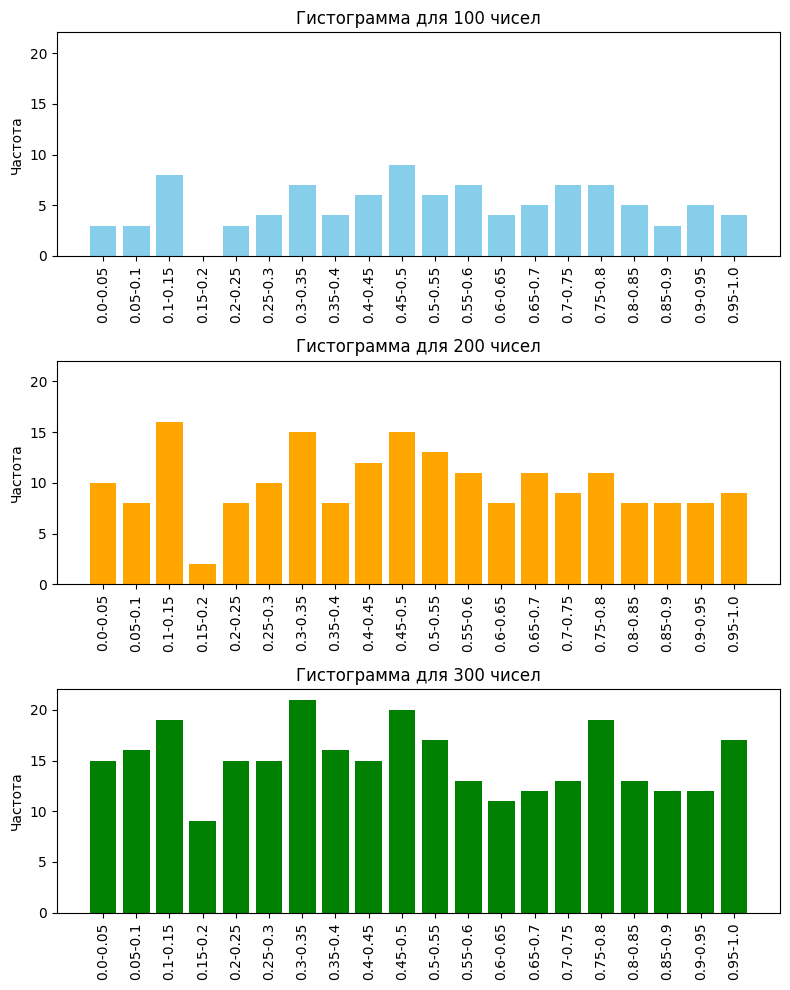

In [627]:
fig, axs = plt.subplots(3, 1, figsize=(8, 10),sharey=True)

axs[0].bar(range(q), counts_100, color="skyblue")
axs[0].set_title("Гистограмма для 100 чисел")

axs[1].bar(range(q), counts_200, color="orange")
axs[1].set_title("Гистограмма для 200 чисел")

axs[2].bar(range(q), counts_300, color="green")
axs[2].set_title("Гистограмма для 300 чисел")

for ax in axs:
    ax.set_ylabel("Частота")
    ax.set_xticks(range(q))
    ax.set_xticklabels([f"{i/20}-{(i+1)/20}" for i in range(q)], rotation=90)

plt.tight_layout()
plt.show()

In [628]:
sample_sizes = np.arange(50, 2000, 100) 
means = []
variances = []

for n in sample_sizes:
    seq = create_seq(best_r0, best_r1, n, best_k)
    means.append(np.mean(seq))
    variances.append(np.var(seq, ddof=0))

In [629]:
points_sizes = [100, 200, 300]

points_means = [np.mean(create_seq(best_r0, best_r1, n, best_k)) for n in points_sizes]
points_vars = [np.var(create_seq(best_r0, best_r1, n, best_k), ddof=0) for n in points_sizes]


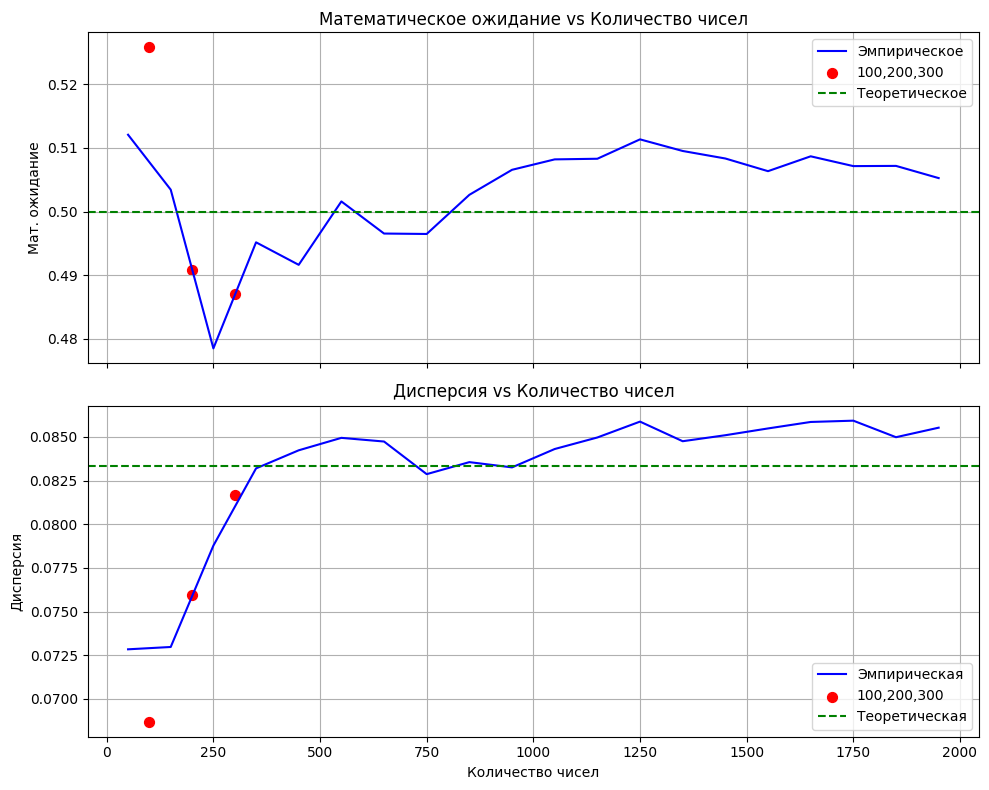

In [630]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Математическое ожидание ---
axes[0].plot(sample_sizes, means, 'b-', label='Эмпирическое')
axes[0].scatter(points_sizes, points_means, color='red', s=50, label='100,200,300')
axes[0].axhline(teor_mean, color='green', linestyle='--', label='Теоретическое')
axes[0].set_ylabel('Мат. ожидание')
axes[0].set_title('Математическое ожидание vs Количество чисел')
axes[0].legend()
axes[0].grid(True)

# --- Дисперсия ---
axes[1].plot(sample_sizes, variances, 'b-', label='Эмпирическая')
axes[1].scatter(points_sizes, points_vars, color='red', s=50, label='100,200,300')
axes[1].axhline(teor_variance, color='green', linestyle='--', label='Теоретическая')
axes[1].set_xlabel('Количество чисел')
axes[1].set_ylabel('Дисперсия')
axes[1].set_title('Дисперсия vs Количество чисел')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [631]:
# Определение длины периода

def period_length(seq):
    seen = {}
    for i, val in enumerate(seq):
        if val in seen:
            start = seen[val]
            return start, i - start  
        seen[val] = i
    return None, len(seq)  

seq = create_seq(best_r0, best_r1, 10000, best_k)
start, period_len = period_length(seq)
print(f'Номер элемента с которого начался повтор: {start} \nДлина периода: {period_len}')


Номер элемента с которого начался повтор: None 
Длина периода: 10000


In [632]:
# Хи квадрат

from scipy.stats import chisquare

seq = create_seq(best_r0, best_r1, 1000, best_k)

intervals = np.linspace(0, 1, q+1)
counts, _ = np.histogram(seq, bins=intervals)

chi2_stat, p_value = chisquare(counts)
print(f"Х: {chi2_stat}, p-value: {p_value}")


Х: 13.599999999999998, p-value: 0.8064901149045073
